In [15]:
import pandas as pd
import numpy as np

# 1 Load Data

In [22]:
# load dataset
df = pd.read_csv('data/LC_loans_granting_model_dataset.csv')
df

C:\Users\JanderM\AppData\Local\Temp\ipykernel_11268\1040761876.py:2: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/LC_loans_granting_model_dataset.csv')


,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,NaN
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,NaN
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,NaN,NaN
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0,Major purchase,NaN
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0,Debt consolidation,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1347676,89905081,Oct-2016,130000.0,20.59,18000,737.0,1,5 years,home_improvement,OWN,TX,775xx,0,Home improvement,NaN
1347677,88948836,Oct-2016,180792.0,22.03,29400,707.0,1,9 years,debt_consolidation,MORTGAGE,CA,900xx,0,Debt consolidation,NaN
1347678,89996426,Oct-2016,157000.0,10.34,32000,737.0,1,3 years,home_improvement,MORTGAGE,AZ,863xx,1,Home improvement,NaN
1347679,90006534,Oct-2016,150000.0,12.25,16000,667.0,1,10+ years,medical,RENT,NC,284xx,0,Medical expenses,NaN


# 2 Prepare Columns

In [4]:
# remove issue_d, desc, experience_c, title, addr_state and zip_code columns
df = df.drop(columns=['issue_d', 'desc', 'experience_c', 'title', 'addr_state', 'zip_code'])
df

,id,revenue,dti_n,loan_amnt,fico_n,emp_length,purpose,home_ownership_n,Default
0,68407277,55000.0,5.91,3600,677.0,10+ years,debt_consolidation,MORTGAGE,0
1,68355089,65000.0,16.06,24700,717.0,10+ years,small_business,MORTGAGE,0
2,68341763,71000.0,13.85,20000,697.0,10+ years,home_improvement,MORTGAGE,0
3,68476807,104433.0,25.37,10400,697.0,3 years,major_purchase,MORTGAGE,0
4,68426831,34000.0,10.20,11950,692.0,4 years,debt_consolidation,RENT,0
...,...,...,...,...,...,...,...,...,...
1347676,89905081,130000.0,20.59,18000,737.0,5 years,home_improvement,OWN,0
1347677,88948836,180792.0,22.03,29400,707.0,9 years,debt_consolidation,MORTGAGE,0
1347678,89996426,157000.0,10.34,32000,737.0,3 years,home_improvement,MORTGAGE,1
1347679,90006534,150000.0,12.25,16000,667.0,10+ years,medical,RENT,0


In [5]:
# print missing values per column
df.isnull().sum()

id                  0
revenue             0
dti_n               0
loan_amnt           0
fico_n              0
emp_length          0
purpose             0
home_ownership_n    0
Default             0
dtype: int64

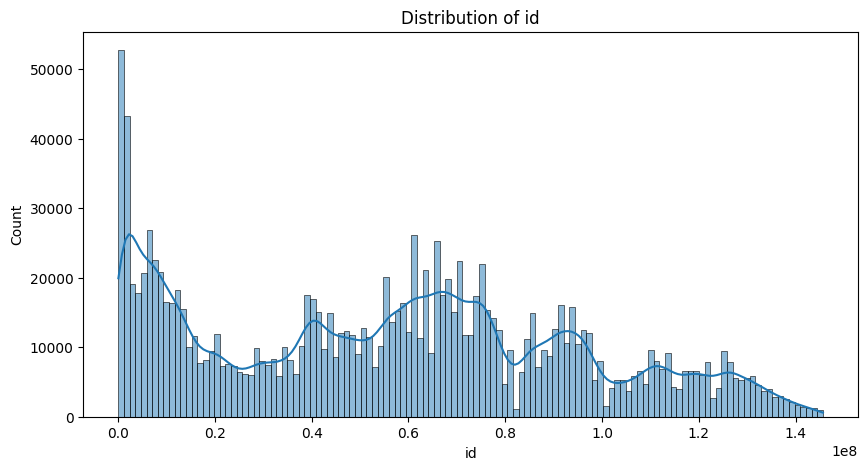

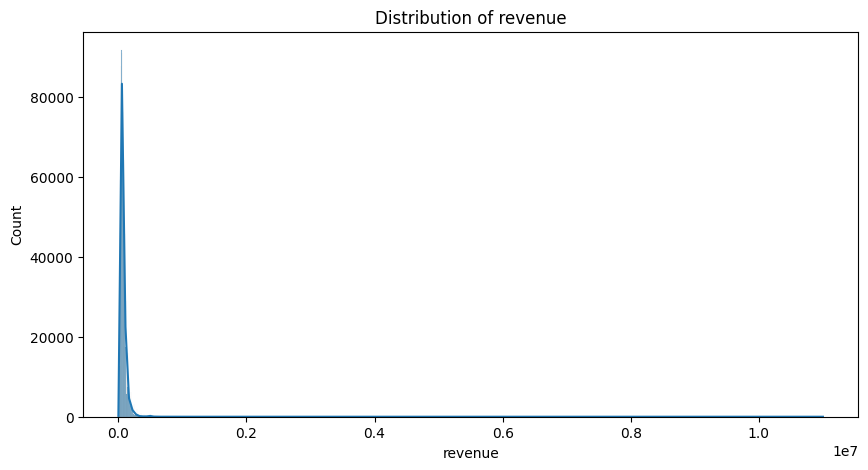

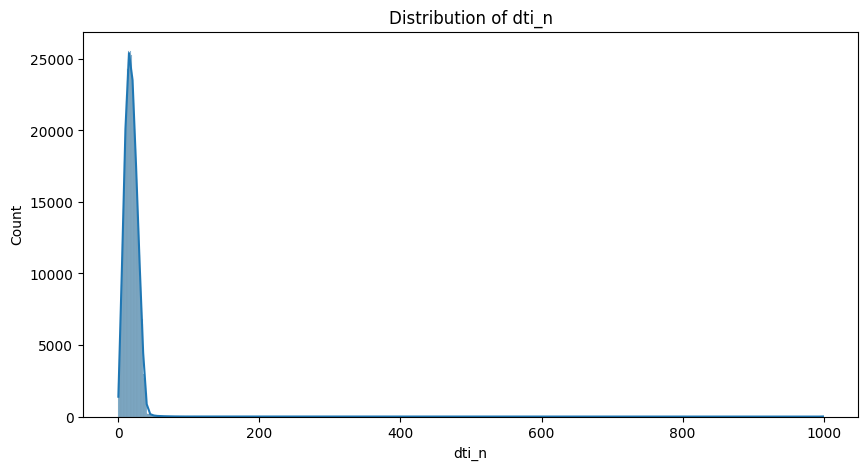

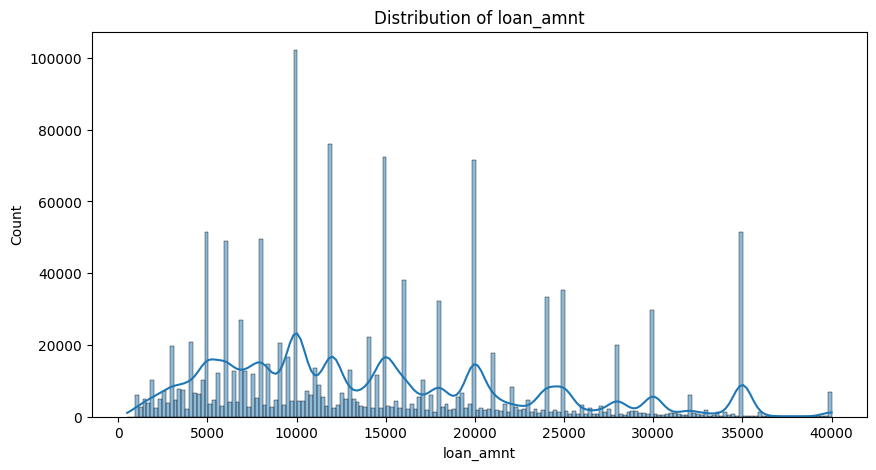

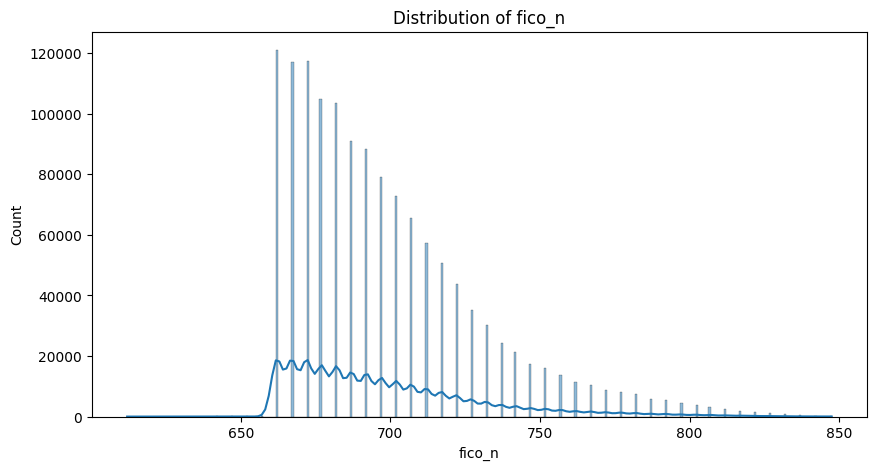

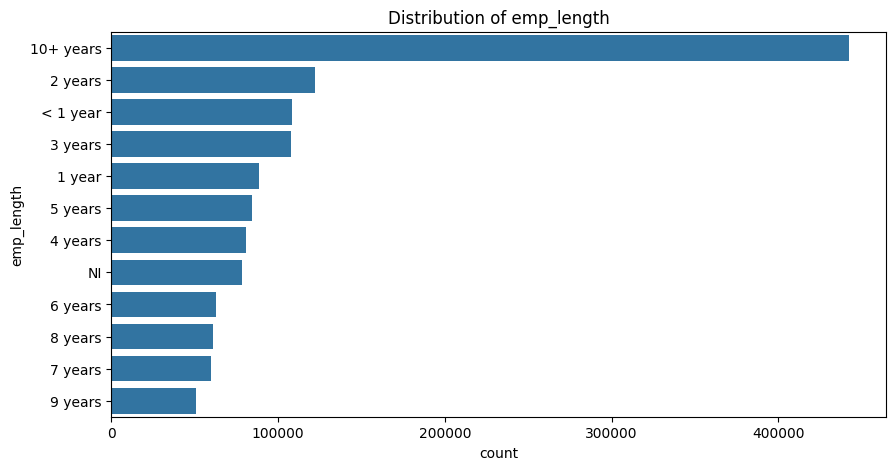

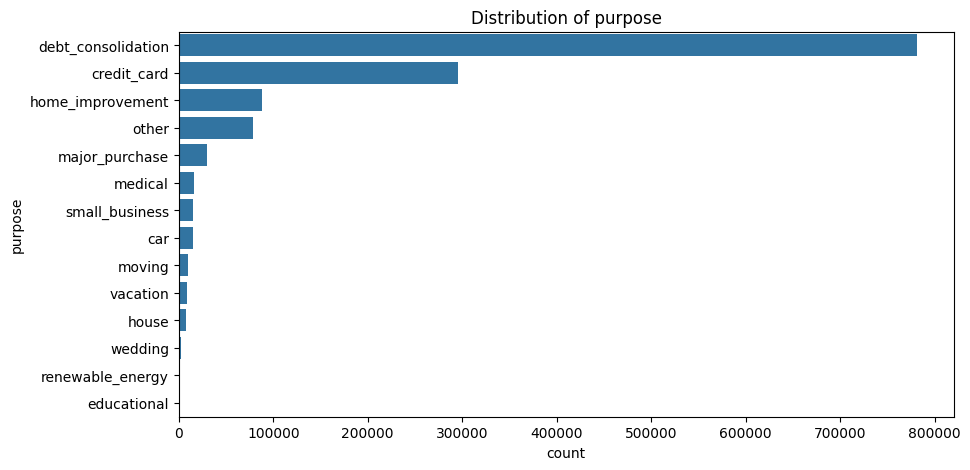

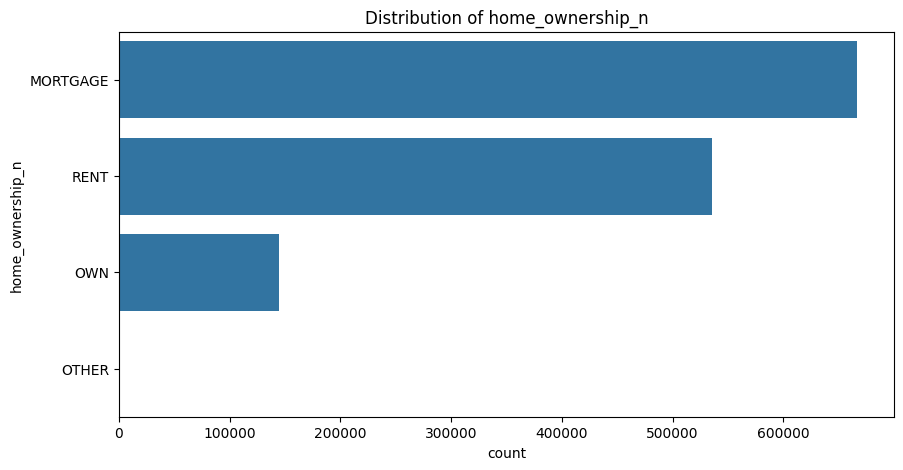

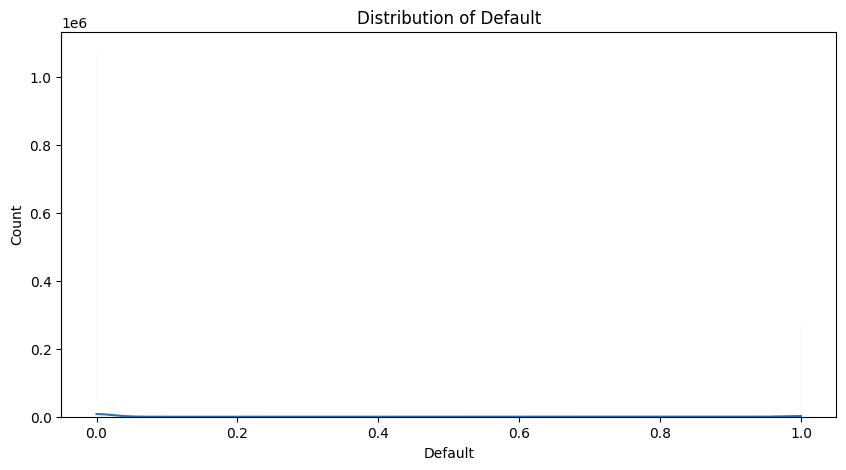

In [6]:
# plot distributions of all columns
import matplotlib.pyplot as plt
import seaborn as sns

for column in df.columns:
    plt.figure(figsize=(10, 5))
    if df[column].dtype == 'object':
        sns.countplot(y=df[column], order=df[column].value_counts().index)
    else:
        sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

In [7]:
# print unique values for purpose column
print(df['purpose'].unique())

['debt_consolidation' 'small_business' 'home_improvement' 'major_purchase'
 'credit_card' 'other' 'house' 'vacation' 'car' 'medical' 'moving'
 'renewable_energy' 'wedding' 'educational']


In [8]:
# convert purpose column in business and personal with 1 indicating business and 0 personal
df['business'] = df['purpose'].apply(lambda x: 1 if x in ['small_business'] else 0) 

df = df.drop(columns=['purpose'])

df

,id,revenue,dti_n,loan_amnt,fico_n,emp_length,home_ownership_n,Default,business
0,68407277,55000.0,5.91,3600,677.0,10+ years,MORTGAGE,0,0
1,68355089,65000.0,16.06,24700,717.0,10+ years,MORTGAGE,0,1
2,68341763,71000.0,13.85,20000,697.0,10+ years,MORTGAGE,0,0
3,68476807,104433.0,25.37,10400,697.0,3 years,MORTGAGE,0,0
4,68426831,34000.0,10.20,11950,692.0,4 years,RENT,0,0
...,...,...,...,...,...,...,...,...,...
1347676,89905081,130000.0,20.59,18000,737.0,5 years,OWN,0,0
1347677,88948836,180792.0,22.03,29400,707.0,9 years,MORTGAGE,0,0
1347678,89996426,157000.0,10.34,32000,737.0,3 years,MORTGAGE,1,0
1347679,90006534,150000.0,12.25,16000,667.0,10+ years,RENT,0,0


In [9]:
# print value counts for business column
print(df['business'].value_counts())

business
0    1332106
1      15575
Name: count, dtype: int64


In [10]:
# make emp_lenght column numerical by removing 'years', 'year', '< 1' and '10+' and converting to int
df['emp_length'] = df['emp_length'].str.replace('years', '').str.replace('year', '').str.replace('< 1', '0').str.replace('10+', '10').str.strip()
df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')

df['emp_length'].value_counts()

emp_length
10.0    442667
2.0     122091
0.0     108517
3.0     107862
1.0      88841
5.0      84326
4.0      80761
6.0      62877
8.0      60808
7.0      59724
9.0      51019
Name: count, dtype: int64

In [11]:
# convert home_ownership_n column to numerical column home_equity with 1 indicating home ownership or mortgage and 0 renting
df['home_equity'] = df['home_ownership_n'].apply(lambda x: 1 if x in ['OWN', 'MORTGAGE'] else 0)
df = df.drop(columns=['home_ownership_n'])
df['home_equity'].value_counts()

home_equity
1    811579
0    536102
Name: count, dtype: int64

In [12]:
# print value_counts for Default column
print(df['Default'].value_counts())


Default
0    1078432
1     269249
Name: count, dtype: int64


In [13]:
# drop id column
df = df.drop(columns=['id'])
df

,revenue,dti_n,loan_amnt,fico_n,emp_length,Default,business,home_equity
0,55000.0,5.91,3600,677.0,10.0,0,0,1
1,65000.0,16.06,24700,717.0,10.0,0,1,1
2,71000.0,13.85,20000,697.0,10.0,0,0,1
3,104433.0,25.37,10400,697.0,3.0,0,0,1
4,34000.0,10.20,11950,692.0,4.0,0,0,0
...,...,...,...,...,...,...,...,...
1347676,130000.0,20.59,18000,737.0,5.0,0,0,1
1347677,180792.0,22.03,29400,707.0,9.0,0,0,1
1347678,157000.0,10.34,32000,737.0,3.0,1,0,1
1347679,150000.0,12.25,16000,667.0,10.0,0,0,0


In [14]:
df

,revenue,dti_n,loan_amnt,fico_n,emp_length,Default,business,home_equity
0,55000.0,5.91,3600,677.0,10.0,0,0,1
1,65000.0,16.06,24700,717.0,10.0,0,1,1
2,71000.0,13.85,20000,697.0,10.0,0,0,1
3,104433.0,25.37,10400,697.0,3.0,0,0,1
4,34000.0,10.20,11950,692.0,4.0,0,0,0
...,...,...,...,...,...,...,...,...
1347676,130000.0,20.59,18000,737.0,5.0,0,0,1
1347677,180792.0,22.03,29400,707.0,9.0,0,0,1
1347678,157000.0,10.34,32000,737.0,3.0,1,0,1
1347679,150000.0,12.25,16000,667.0,10.0,0,0,0


# 3 Prepare Train and Test Set

1. Train-test split
2. Train set undersampling
3. Feature scaling

In [ ]:
# prepare trainset and test set with 80% training and 20% test data
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Default']).to_numpy()
y = df['Default'].to_numpy()

print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)



(1347681, 7) (1347681,)
(1078144, 7) (1078144,) (269537, 7) (269537,)


In [17]:
# undersample the majority class to have the same number of samples as the minority class

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)
print(X_train_res.shape, y_train_res.shape)

(430798, 7) (430798,)


In [18]:
# scale the data with StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_res)                 # fit on training data only
X_train_scaled = scaler.transform(X_train_res)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape, X_test_scaled.shape)

(430798, 7) (269537, 7)


In [21]:
X_train_scaled

array([[ 2.87282209, -0.56014299,  1.72342181, ...,  0.83209483,
        -0.11793875,  0.85548712],
       [-0.30625319,  0.90812126,  0.51150574, ..., -0.52068714,
        -0.11793875,  0.85548712],
       [-0.70914703, -1.68387837, -1.17834905, ..., -1.60291271,
        -0.11793875, -1.16892467],
       ...,
       [ 0.42737957,  0.70997253,  2.29239649, ...,  1.10265123,
        -0.11793875,  0.85548712],
       [ 0.06775567,  0.17979078,  0.01649777, ..., -0.79124353,
        -0.11793875, -1.16892467],
       [-0.30625319, -0.56192812, -0.32488703, ..., -0.25013074,
        -0.11793875, -1.16892467]], shape=(430798, 7))

In [23]:
# save processed data to npy files
np.save('data/X_train.npy', X_train_scaled)
np.save('data/y_train.npy', y_train_res)
np.save('data/X_test.npy', X_test_scaled)
np.save('data/y_test.npy', y_test)

print("Data preprocessing complete and saved to npy files.")

Data preprocessing complete and saved to npy files.
